In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [7]:
df = pd.DataFrame(columns=["Model","Data", "Quality Measure", "k", "Total", "Positive", "Negative"])

for file in os.listdir("./results/"):
    if not file.endswith(".txt") or not file.startswith("BSD_"):
        continue
    file_name = file.split(".txt")[0]
    file_args = file_name.split("_")
    data = file_args[1]
    k = int(file_args[-1])
    if len(file_args) == 4:
        quality = file_args[2]
    else:
        quality = "WRAcc"

    with open(f"./results/{file}", "r") as f:
        lines = f.readlines()
        total = float(lines[0].split(": ")[1])
        positive = float(lines[1].split(": ")[1])
        negative = float(lines[2].split(": ")[1])
        df.loc[len(df)] = ["BSD", data, quality, k, total, positive, negative]


In [8]:
df["Youden's J index"] = df["Positive"] - df["Negative"]

In [9]:
df_d = df[df["Data"] == "Cardio"]
df_d[df_d["Youden's J index"] == df_d["Youden's J index"].max()]

,Model,Data,Quality Measure,k,Total,Positive,Negative,Youden's J index
14,BSD,Cardio,BinomialTest,190,0.304821,0.392353,0.217384,0.17497
184,BSD,Cardio,BinomialTest,160,0.304821,0.392353,0.217384,0.17497
208,BSD,Cardio,BinomialTest,220,0.304821,0.392353,0.217384,0.17497
239,BSD,Cardio,BinomialTest,130,0.304821,0.392353,0.217384,0.17497


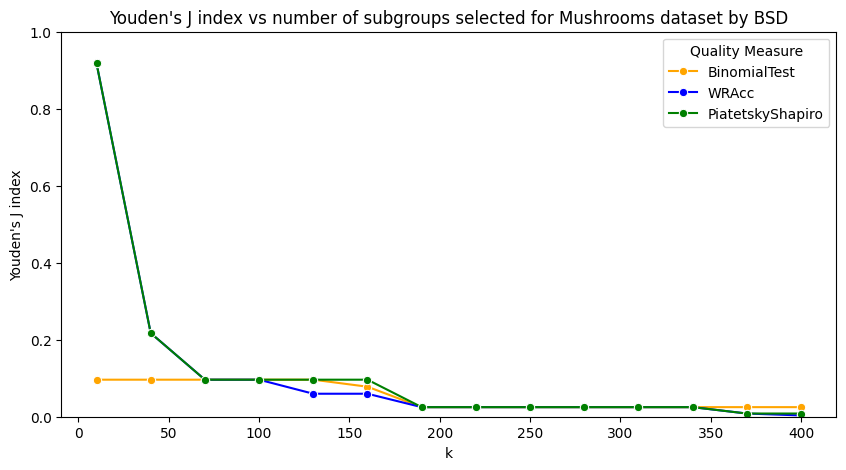

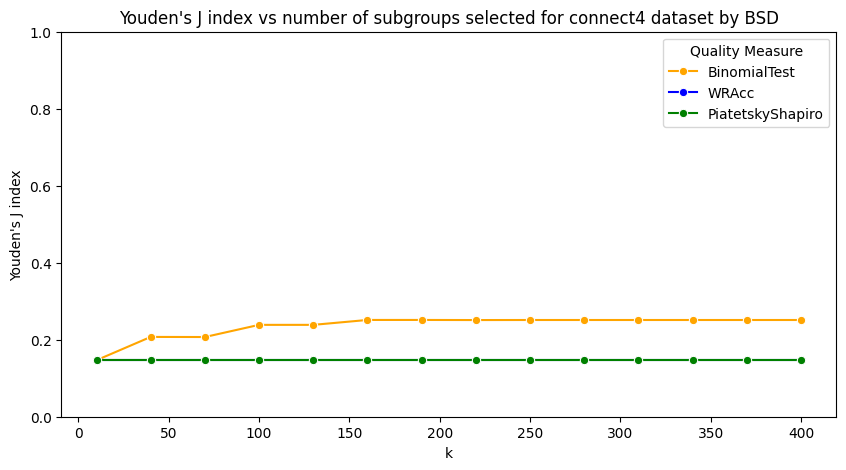

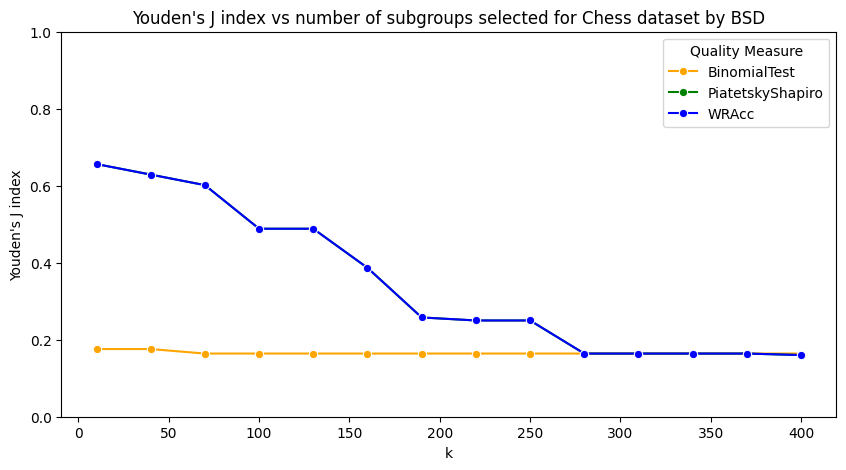

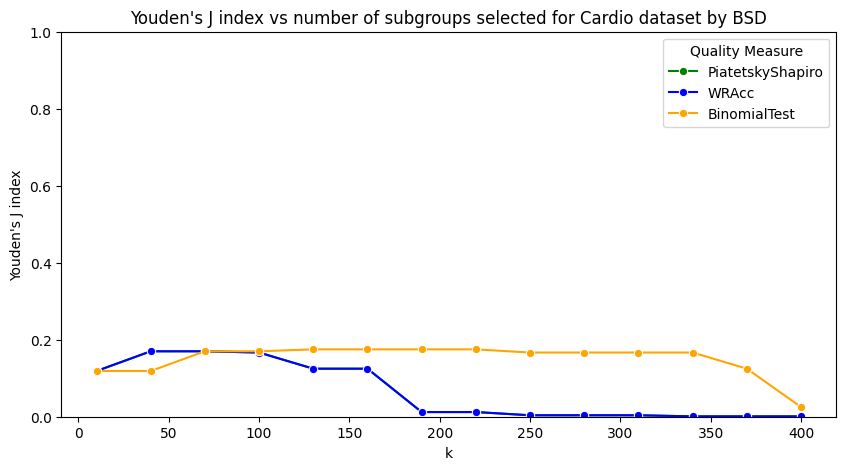

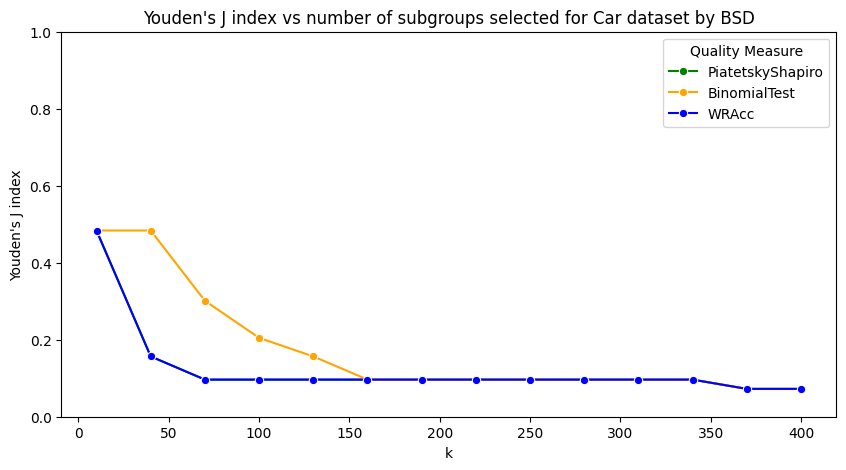

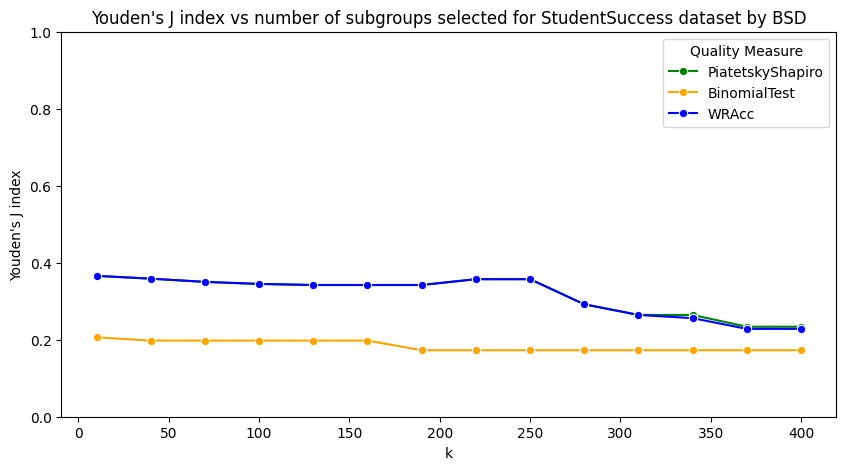

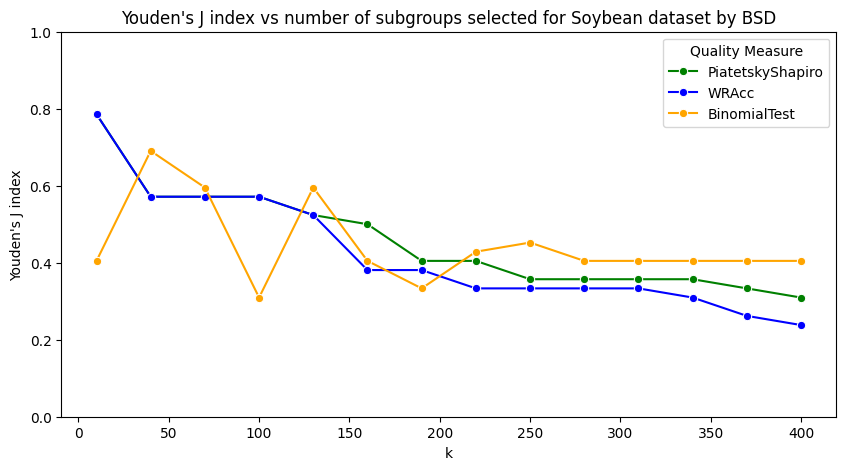

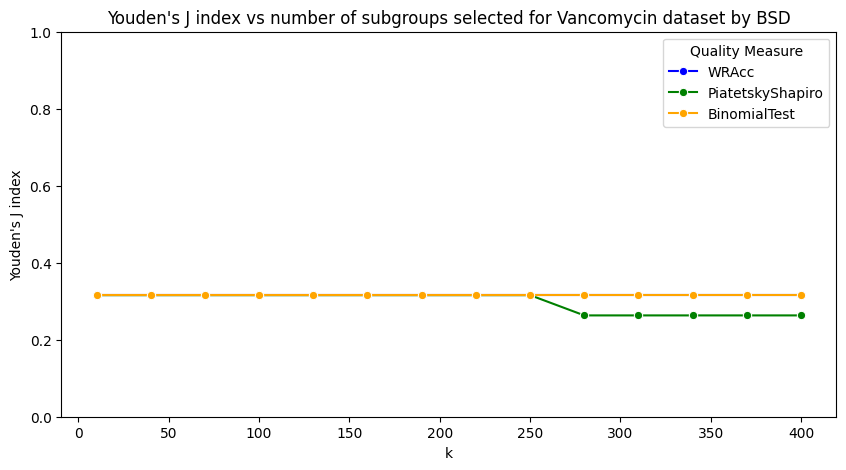

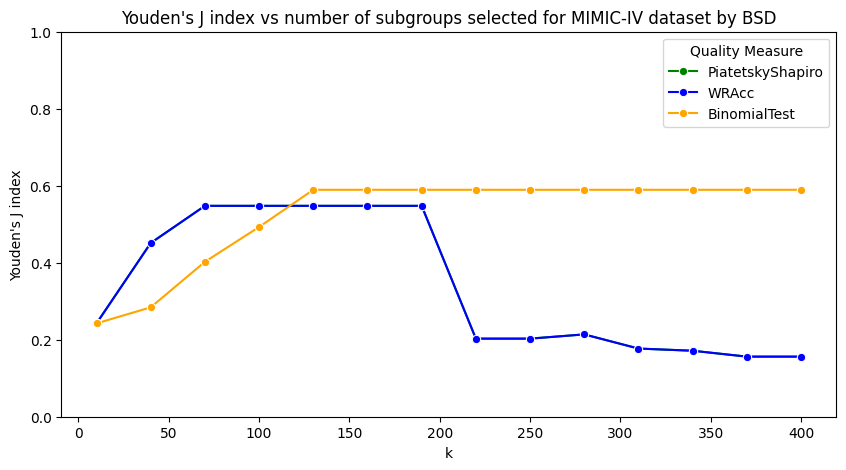

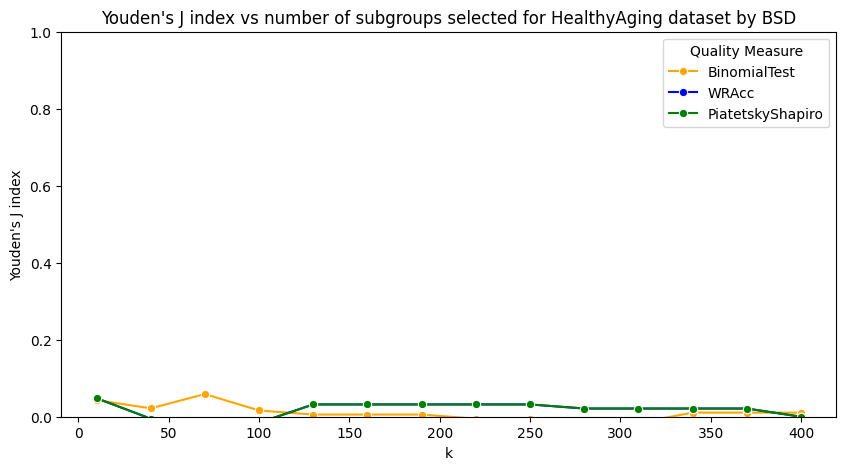

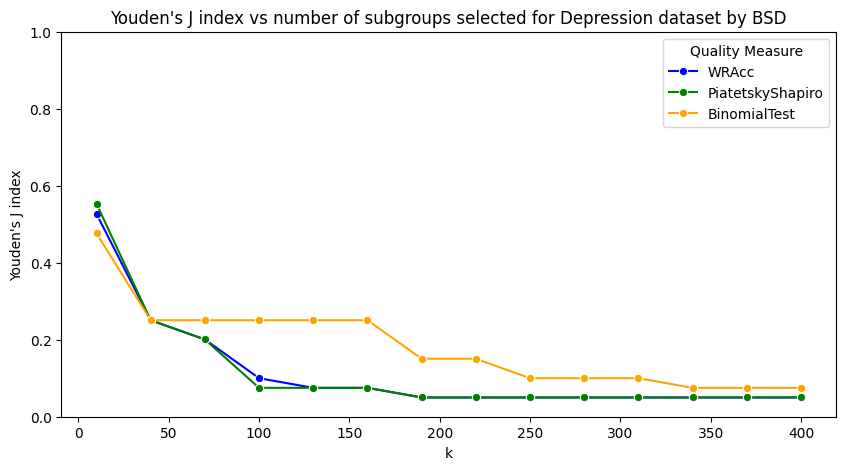

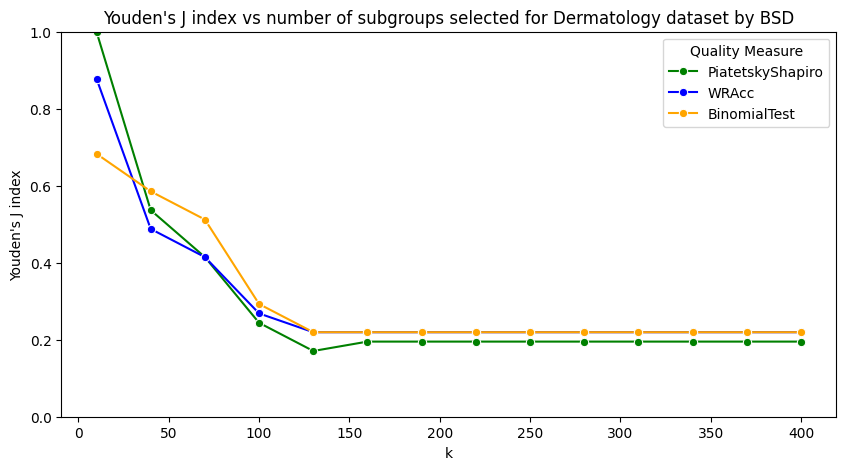

In [10]:
color_map = {
    "WRAcc": "blue",
    "BinomialTest": "orange",
    "PiatetskyShapiro": "green"
}

for d in df["Data"].unique():
    fig = plt.figure(figsize=(10, 5))
    sns.lineplot(x = "k", y = "Youden's J index", hue = "Quality Measure", data = df[df["Data"] == d], marker="o", palette=color_map)
    plt.title(f"Youden's J index vs number of subgroups selected for {d} dataset by BSD")
    plt.ylim(0, 1)
    plt.savefig(f"./plots/BSD_{d}_Youden.png")